<a href="https://colab.research.google.com/github/PalomaSoaresR/FATEC-API-6-SEMESTRE/blob/docs-add-tutorial-notebooks/_PT_e_PNT_por_Conjunto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perda Técnica e Não Técnica - Análise e Integração das Planilhas SSDMT, CONJ e CTMT

Este notebook realiza o pipeline completo de tratamento e linkagem das três planilhas para gerar a %PT e %PNT por Conjunto

##  Guia: Como Adicionar Novas Concessionárias e Dados

Este notebook foi estruturado para ser modular. Para processar dados de uma nova concessionária ou atualizar os atuais, siga os passos abaixo:

### 1. Processando novas planilhas

1. **Upload dos arquivos**: Clique no ícone de **pasta** na barra lateral esquerda do Google Colab e arraste seus arquivos `SSDMT.xlsx`, `CONJ.xlsx` e `CTMT.xlsx` para dentro dela.
2. **Nomes dos arquivos**: Certifique-se de que os nomes estão exatamente como citado acima (o sistema diferencia maiúsculas de minúsculas).
3. **Executar**: No menu superior, clique em **Ambiente de Execução** e selecione **Executar tudo**.
4. **Verificação**: O gráfico e as tabelas ao final do notebook serão atualizados automaticamente com os novos dados carregados.

### 2. Preparação dos Arquivos
Certifique-se de que os arquivos Excel estão no diretório `/content/` com os nomes exatos:
- `SSDMT.xlsx`: Deve conter as colunas `CTMT` e `CONJ`.
- `CONJ.xlsx`: Deve conter `COD_ID` e `NOM`.
- `CTMT.xlsx`: Deve conter as colunas de energia (`ENE_01` a `ENE_12`), perdas técnicas (`PERD_...`) e perdas não técnicas (`PNTMT_...`, `PNTBT_...`).

### 3. Atualização do Caminho (Se necessário)
Se os nomes dos arquivos mudarem, altere a primeira célula de código (ID: `4d19c5ca`):
```python
ssdmt = pd.read_excel('/content/NOVO_NOME_SSDMT.xlsx')
```

### 4. Execução em Cadeia
Após substituir os arquivos no menu lateral do Colab:
1. Vá em **Ambiente de Execução** (Runtime).
2. Clique em **Executar Tudo** (Run all).

### 5. Verificação de Colunas
Se a nova concessionária utilizar nomes de colunas diferentes para Perdas (ex: `PERD_TOTAL` em vez de decompostas), você deve ajustar a lista `colunas_PT` na **Etapa 3a**.

### 6. Customização do Gráfico
O gráfico de barras empilhadas (última célula) se ajusta automaticamente ao número de conjuntos. Se houver muitos conjuntos, a variável `figsize` na linha `fig, ax = plt.subplots(figsize=(14, max(6, len(tabela_agrupada) * 0.5)))` garantirá que o gráfico cresça verticalmente para manter a legibilidade.

In [ ]:
import pandas as pd
import os
!pip install openpyxl

# Lê os arquivos
ssdmt = pd.read_excel('/content/SSDMT.xlsx')
conj  = pd.read_excel('/content/CONJ.xlsx')
ctmt  = pd.read_excel('/content/CTMT.xlsx')

## Etapa 1 — Tratamento da planilha SSDMT

Selecionar as colunas `CTMT` e `CONJ`, mantendo apenas valores distintos.

In [ ]:
ssdmt_tratado = ssdmt[['CTMT', 'CONJ']].drop_duplicates().reset_index(drop=True)

print(f'Registros distintos SSDMT: {len(ssdmt_tratado)}')
ssdmt_tratado.head(10)

Registros distintos SSDMT: 706


,CTMT,CONJ
0,ADT01L3,15845
1,MCA01L1,15857
2,BRT01C3,13251
3,MRG01C4,16567
4,AQZ01I1,15853
5,ESB01S4,15858
6,ART01N5,13242
7,BBL01M5,13248
8,MTI01P4,13332
9,PCJ01P5,13355


## Etapa 2 — Linkagem com a planilha CONJ

Linkar a coluna `COD_ID` da planilha CONJ com a coluna `CONJ` do SSDMT tratado,
retornando a coluna `NOM` e unindo as tabelas.

In [ ]:
conj_select = conj[['COD_ID', 'NOM']].rename(columns={'COD_ID': 'CONJ'})

ssdmt_conj = ssdmt_tratado.merge(conj_select, on='CONJ', how='left')

print(f'Registros após join SSDMT + CONJ: {len(ssdmt_conj)}')
ssdmt_conj.head(10)

Registros após join SSDMT + CONJ: 706


,CTMT,CONJ,NOM
0,ADT01L3,15845,ALDEOTA
1,MCA01L1,15857,MACAOCA
2,BRT01C3,13251,BATURIT?
3,MRG01C4,16567,MARANGUAPE
4,AQZ01I1,15853,AQUIRAZ
5,ESB01S4,15858,EUS?BIO
6,ART01N5,13242,ARACATI
7,BBL01M5,13248,BARBALHA
8,MTI01P4,13332,MAURITI
9,PCJ01P5,13355,PACAJUS


## Etapa 3 — Tratamento da planilha CTMT

### 3a) Somar colunas de Perda Total

As colunas abaixo são somadas em uma única coluna chamada **Perda Total**:

`PERD_A3a, PERD_A4, PERD_B, PERD_MED, PERD_A3a_B, PERD_A4_B, PERD_B_A3a, PERD_B_A4,
PNTMT_01..12, PNTBT_01..12, DESCR, PERD_A3aA4, PERD_A4A3a`

In [ ]:
colunas_PT = [
    'PERD_A3a', 'PERD_A4', 'PERD_B', 'PERD_MED',
    'PERD_A3a_B', 'PERD_A4_B', 'PERD_B_A3a', 'PERD_B_A4',
    'PERD_A3aA4', 'PERD_A4A3a'
]

colunas_PNT = ['PNTMT_01', 'PNTMT_02', 'PNTMT_03', 'PNTMT_04', 'PNTMT_05', 'PNTMT_06',
    'PNTMT_07', 'PNTMT_08', 'PNTMT_09', 'PNTMT_10', 'PNTMT_11', 'PNTMT_12',
    'PNTBT_01', 'PNTBT_02', 'PNTBT_03', 'PNTBT_04', 'PNTBT_05', 'PNTBT_06',
    'PNTBT_07', 'PNTBT_08', 'PNTBT_09', 'PNTBT_10', 'PNTBT_11', 'PNTBT_12']

# Filtrar apenas as colunas numéricas (excluir DESCR que é texto)
colunas_PT_num = [c for c in colunas_PT if c in ctmt.columns and pd.api.types.is_numeric_dtype(ctmt[c])]
colunas_PNT_num = [c for c in colunas_PNT if c in ctmt.columns and pd.api.types.is_numeric_dtype(ctmt[c])]

ctmt['Perda Técnica'] = ctmt[colunas_PT_num].sum(axis=1)
ctmt['Perda Não Técnica'] = ctmt[colunas_PNT_num].sum(axis=1)

# Converter para MWh
ctmt['Perda Técnica (MWh)'] = ctmt['Perda Técnica'] / 1000
ctmt['Perda Não Técnica (MWh)'] = ctmt['Perda Não Técnica'] / 1000

ctmt[['COD_ID', 'Perda Técnica (MWh)','Perda Não Técnica (MWh)']].head(5)

,COD_ID,Perda Técnica (MWh),Perda Não Técnica (MWh)
0,ACA01CA,0.0000,0.00000
1,ACA01C1,6208.5030,555.01361
2,ACA01C2,2937.0180,312.63609
3,ACA01C3,3310.7865,500.58351
4,ACA01C4,3995.6490,378.60621


### 3b) Somar colunas de Energia Injetada

As colunas `ENE_01` a `ENE_12` são somadas em uma única coluna chamada **Energia Injetada**.

In [ ]:
colunas_ene = [
    'ENE_01', 'ENE_02', 'ENE_03', 'ENE_04', 'ENE_05', 'ENE_06',
    'ENE_07', 'ENE_08', 'ENE_09', 'ENE_10', 'ENE_11', 'ENE_12'
]

ctmt['Energia Injetada'] = ctmt[colunas_ene].sum(axis=1)

# Converter para MWh
ctmt['Energia Injetada (Mwh)'] = ctmt['Energia Injetada'] / 1000

ctmt[['COD_ID', 'Energia Injetada (Mwh)']].head(5)

,COD_ID,Energia Injetada (Mwh)
0,ACA01CA,1546.52366
1,ACA01C1,37978.98147
2,ACA01C2,23003.72962
3,ACA01C3,39331.00340
4,ACA01C4,25390.65433


## Etapa 4 — Linkagem Final

Linkar a coluna `COD_ID` da planilha CTMT com a coluna `CTMT` da tabela SSDMT+CONJ.

O resultado é a tabela unificada final.

In [ ]:
ctmt_select = ctmt[['COD_ID', 'Perda Não Técnica (MWh)', 'Perda Técnica (MWh)','Energia Injetada (Mwh)']].rename(columns={'COD_ID': 'CTMT'})

tabela_final = ssdmt_conj.merge(ctmt_select, on='CTMT', how='left')

#Agrupamento por Conjunto
tabela_agrupada = tabela_final.groupby('NOM')[[
    'Perda Não Técnica (MWh)',
    'Perda Técnica (MWh)',
    'Energia Injetada (Mwh)'
]].sum().reset_index()

# % Perda Técnica em relação a Energia Injetada
tabela_agrupada['% PT'] = (
    tabela_agrupada['Perda Técnica (MWh)'] /
    tabela_agrupada['Energia Injetada (Mwh)'].replace(0, pd.NA)
) * 100

# % Perda Não Técnica em relação a Energia Injetada
tabela_agrupada['% PNT'] = (
    tabela_agrupada['Perda Não Técnica (MWh)'] /
    tabela_agrupada['Energia Injetada (Mwh)'].replace(0, pd.NA)
) * 100

#Total de Perda
tabela_agrupada["Perda Total"] = tabela_agrupada['Perda Não Técnica (MWh)'] + tabela_agrupada['Perda Técnica (MWh)']

# %Perda Técnica em relação a perda total
tabela_agrupada['% PNT_Perda_Total'] = (
    tabela_agrupada['Perda Não Técnica (MWh)'] /
    tabela_agrupada['Perda Total'].replace(0, pd.NA)
) * 100

# %Perda Não Técnica em relação a perda total
tabela_agrupada['% PT_Perda_Total'] = (
    tabela_agrupada['Perda Técnica (MWh)'] /
    tabela_agrupada['Perda Total'].replace(0, pd.NA)
) * 100

#Ordem descrescente com base na Perda perda total
tabela_agrupada = tabela_agrupada.sort_values('Perda Total', ascending=True).reset_index(drop=True)

print(f'Registros na tabela final: {len(tabela_agrupada)}')
print(f'Colunas: {tabela_agrupada.columns.tolist()}')
tabela_agrupada.head(10)

Registros na tabela final: 113
Colunas: ['NOM', 'Perda Não Técnica (MWh)', 'Perda Técnica (MWh)', 'Energia Injetada (Mwh)', '% PT', '% PNT', 'Perda Total', '% PNT_Perda_Total', '% PT_Perda_Total']


,NOM,Perda Não Técnica (MWh),Perda Técnica (MWh),Energia Injetada (Mwh),% PT,% PNT,Perda Total,% PNT_Perda_Total,% PT_Perda_Total
0,CEDRO,154.29541,1846.4565,19901.18029,9.278126,0.775308,2000.75191,7.711871,92.288129
1,ARARIPE,206.35556,2022.3315,16652.45311,12.144346,1.239190,2228.68706,9.259064,90.740936
2,BANABUI?,87.95638,2222.8920,16675.75147,13.330086,0.527451,2310.84838,3.806238,96.193762
3,GUAIUBA,0.00000,2454.2595,28705.50778,8.549786,0.000000,2454.25950,0.000000,100.000000
4,PEDRA BRANCA,135.57228,2447.4240,21395.91210,11.438746,0.633636,2582.99628,5.248644,94.751356
5,CARIR?,148.65577,2768.0940,23053.42413,12.007301,0.644832,2916.74977,5.096624,94.903376
6,INDEPEND?NCIA,294.83496,2863.5810,21445.10629,13.353074,1.374836,3158.41596,9.334900,90.665100
7,APUIAR?S,19.93108,3402.5880,25866.40695,13.154467,0.077054,3422.51908,0.582351,99.417649
8,SANTA QUIT?RIA,763.41530,2767.4325,32576.59883,8.495155,2.343447,3530.84780,21.621303,78.378697
9,OR?S,287.79524,3514.8120,28034.65741,12.537382,1.026569,3802.60724,7.568366,92.431634


# Gráfico de pilha - Perda Técnica e Não Técnica

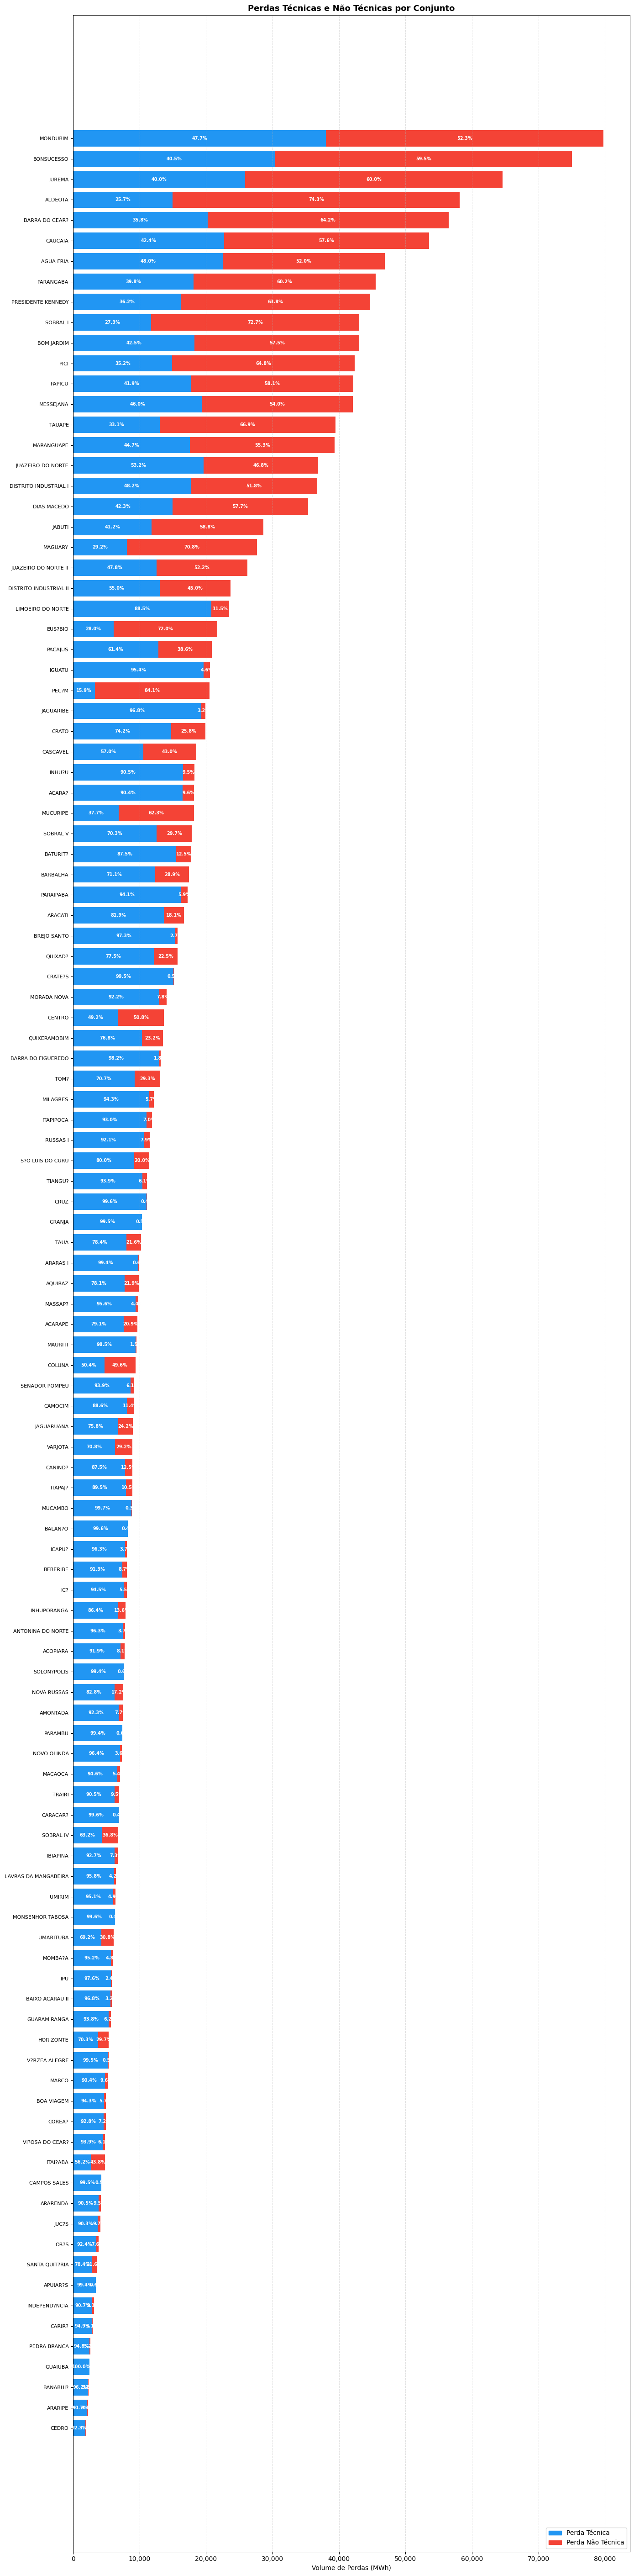

In [ ]:
!pip install matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(14, max(6, len(tabela_agrupada) * 0.5)))

y = np.arange(len(tabela_agrupada))
nomes = tabela_agrupada['NOM']

bars_pt  = ax.barh(y, tabela_agrupada['Perda Técnica (MWh)'],
                   color='#2196F3', label='Perda Técnica')
bars_pnt = ax.barh(y, tabela_agrupada['Perda Não Técnica (MWh)'],
                   left=tabela_agrupada['Perda Técnica (MWh)'],
                   color='#F44336', label='Perda Não Técnica')

# % dentro de cada barra
for i, row in tabela_agrupada.iterrows():
    pt  = row['Perda Técnica (MWh)']
    pnt = row['Perda Não Técnica (MWh)']
    pct_pt  = row['% PT_Perda_Total']
    pct_pnt = row['% PNT_Perda_Total']

    if pt > 0:
        ax.text(pt / 2, i, f"{pct_pt:.1f}%",
                ha='center', va='center', fontsize=7, color='white', fontweight='bold')
    if pnt > 0:
        ax.text(pt + pnt / 2, i, f"{pct_pnt:.1f}%",
                ha='center', va='center', fontsize=7, color='white', fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(nomes, fontsize=8)
ax.set_xlabel('Volume de Perdas (MWh)')
ax.set_title('Perdas Técnicas e Não Técnicas por Conjunto', fontsize=13, fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#2196F3', label='Perda Técnica'),
    mpatches.Patch(color='#F44336', label='Perda Não Técnica')
], loc='lower right')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()